## Project Objectives

### General Objective
To apply basic machine learning techniques to analyse student data, build predictive 
models, evaluate their performance, and interpret results to support early 
identification of academic risk.

### Specific Objectives
By the end of this project, the following will be achieved:

1. Collect and describe a suitable dataset containing student behavioral and 
   academic performance data.
2. Clean and prepare the dataset for machine learning, including handling missing 
   values, duplicates, and categorical encoding.
3. Perform exploratory data analysis to identify patterns and relationships between 
   student behavior and academic performance.
4. Train and compare supervised classification models (Logistic Regression, Decision 
   Tree, and a Neural Network) to predict student performance categories.
5. Apply K-Means clustering to uncover natural behavioral groupings among students.
6. Evaluate model performance using accuracy, precision, recall, and F1-score.
7. Interpret the results and provide practical, ethically-grounded recommendations 
   for real-world use.

In [2]:
# For Data handling
import pandas as pd
import numpy as np

# For Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# For Data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# For the Supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# For the Unsupervised model
from sklearn.cluster import KMeans

# For NN 
from sklearn.neural_network import MLPClassifier

# For Eval
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Makes the plots a lot nicer 
sns.set(style="whitegrid")

# Section 1: Load the dataset

In [35]:
# Load the CSV file into a pandas DataFrame called df
df = pd.read_csv("student_performance.csv")

# Display the first 5 rows to visually check the data loaded correctly
df.head()

,student_id,hours_studied,attendance_percent,sleep_hours,assignment_score,previous_scores,extracurricular,exam_score,performance_category
0,1,6.0,91.1,8.2,81.7,54.9,No,71.1,Distinction
1,2,4.7,100.0,7.6,61.7,62.8,No,75.9,Distinction
2,3,6.3,63.2,6.6,57.7,53.1,Yes,58.5,Fail
3,4,8.0,86.8,5.7,69.9,60.4,Yes,76.9,Distinction
4,5,4.5,72.2,7.3,67.4,36.6,Yes,54.1,Fail


In [36]:
# Show data types
df.info()
# Show statistical summary 
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            501 non-null    int64  
 1   hours_studied         501 non-null    float64
 2   attendance_percent    501 non-null    float64
 3   sleep_hours           494 non-null    float64
 4   assignment_score      493 non-null    float64
 5   previous_scores       501 non-null    float64
 6   extracurricular       501 non-null    object 
 7   exam_score            501 non-null    float64
 8   performance_category  501 non-null    object 
dtypes: float64(6), int64(1), object(2)
memory usage: 35.4+ KB


,student_id,hours_studied,attendance_percent,sleep_hours,assignment_score,previous_scores,exam_score
count,501.000000,501.000000,501.000000,494.000000,493.000000,501.000000,501.00000
mean,250.021956,5.006786,80.147106,6.631174,70.346045,64.780439,64.51477
std,144.733346,1.922788,11.230995,1.181123,14.450835,14.205578,9.75517
min,1.000000,0.000000,47.600000,4.000000,25.900000,30.000000,37.60000
25%,125.000000,3.600000,72.900000,5.800000,60.800000,55.100000,57.70000
50%,250.000000,5.000000,80.300000,6.600000,69.900000,64.900000,64.20000
75%,375.000000,6.300000,87.800000,7.400000,80.500000,75.000000,71.40000
max,500.000000,10.000000,100.000000,9.000000,100.000000,100.000000,92.80000


In [37]:
# Count missing (NaN) values in each column
df.isnull().sum()

student_id              0
hours_studied           0
attendance_percent      0
sleep_hours             7
assignment_score        8
previous_scores         0
extracurricular         0
exam_score              0
performance_category    0
dtype: int64

In [7]:
# Check how many duplicate rows exist in the dataset
df.duplicated().sum()

np.int64(1)

In [39]:
# Remove the duplicate row, keeping the first occurrence
df = df.drop_duplicates()
# Fill missing values in sleep_hours with the column's median
df["sleep_hours"] = df["sleep_hours"].fillna(df["sleep_hours"].median())
# Fill missing values in assignment_score with the column's median
df["assignment_score"] = df["assignment_score"].fillna(df["assignment_score"].median())
# Confirm no missing values 
df.isnull().sum()

student_id              0
hours_studied           0
attendance_percent      0
sleep_hours             0
assignment_score        0
previous_scores         0
extracurricular         0
exam_score              0
performance_category    0
dtype: int64

# Encoding Categorical variables

In [9]:
# Convert extracurricular (Yes/No) into numeric values (1 = Yes, 0 = No)
df["extracurricular"] = df["extracurricular"].map({"Yes": 1, "No": 0})

# Confirm the conversion worked
df["extracurricular"].value_counts()

extracurricular
0    292
1    208
Name: count, dtype: int64

# Section 2: Feature selection & train-test split

In [10]:
# Define features (X) - drop columns that shouldn't be used for prediction
# student_id is just an identifier, not a real feature
# exam_score is dropped because performance_category was directly derived from it 
# using it would be data leakage 
X = df.drop(["student_id", "exam_score", "performance_category"], axis=1)

# Define the target (y) - what we're trying to predict
y = df["performance_category"]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Confirm the shapes of each split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (400, 6)
X_test shape: (100, 6)
y_train shape: (400,)
y_test shape: (100,)


# Section 3: Exploratory Data analysis 

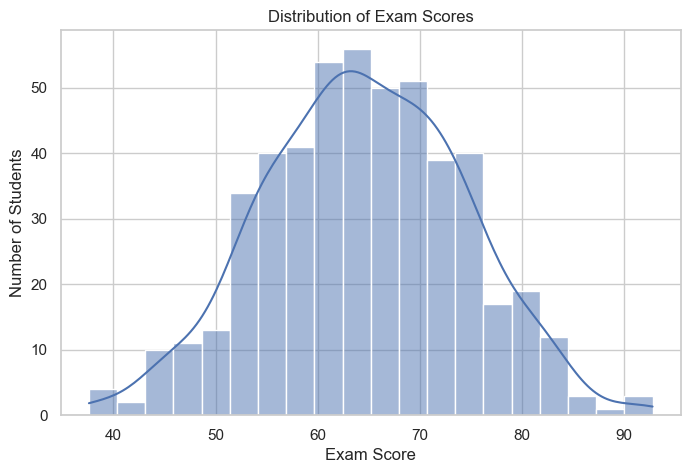

In [ ]:
# Plotting the distribution of exam_score 
plt.figure(figsize=(8, 5))
sns.histplot(df["exam_score"], kde=True, bins=20)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

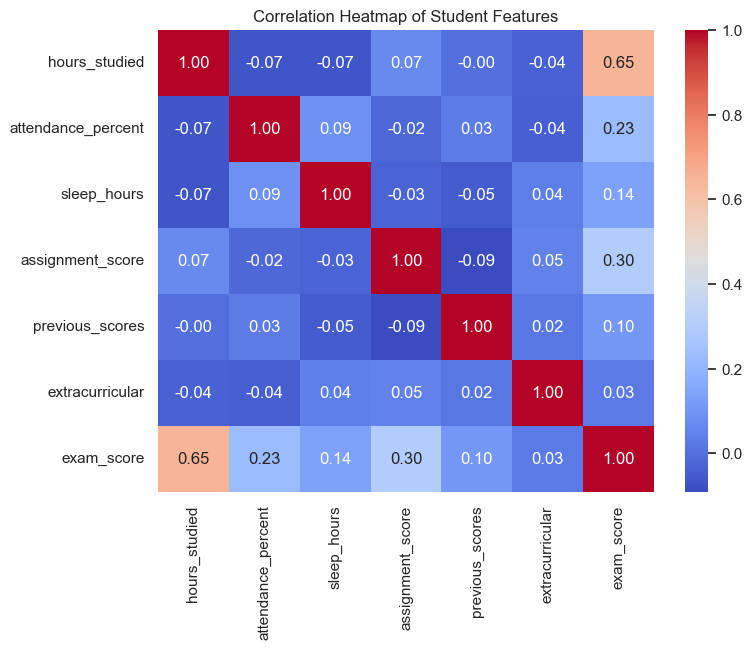

In [ ]:
# Correlation between numeric features and exam_score
plt.figure(figsize=(8, 6))
corr = df.drop(["student_id", "performance_category"], axis=1).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Student Features")
plt.show()

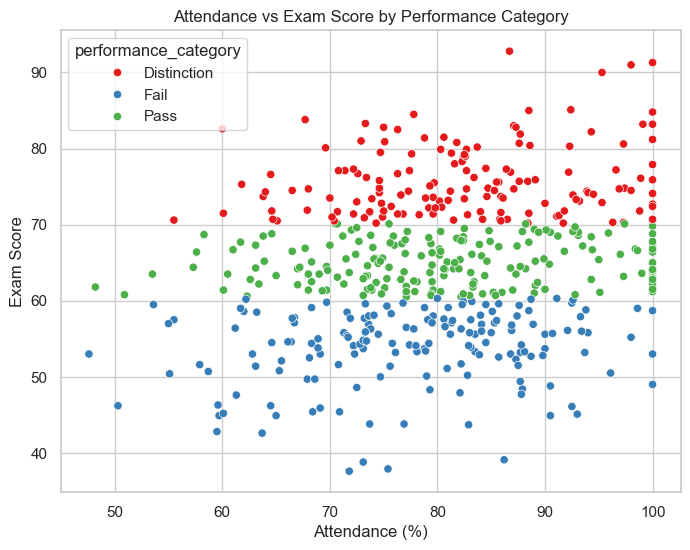

In [13]:
# Scatter plot showing how attendance relates to exam score, split by category
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="attendance_percent", y="exam_score",
    hue="performance_category", palette="Set1"
)
plt.title("Attendance vs Exam Score by Performance Category")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.show()

# Section 4: Supervised model - Logistic Regression

In [15]:
# Scale features so they're on a similar range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Create and train the logistic regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Section 5: Decision tree mdoel 

In [18]:
# Create and train the decision tree model
# max_depth=3 limits how deep the tree can grow
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_tree = tree_model.predict(X_test)

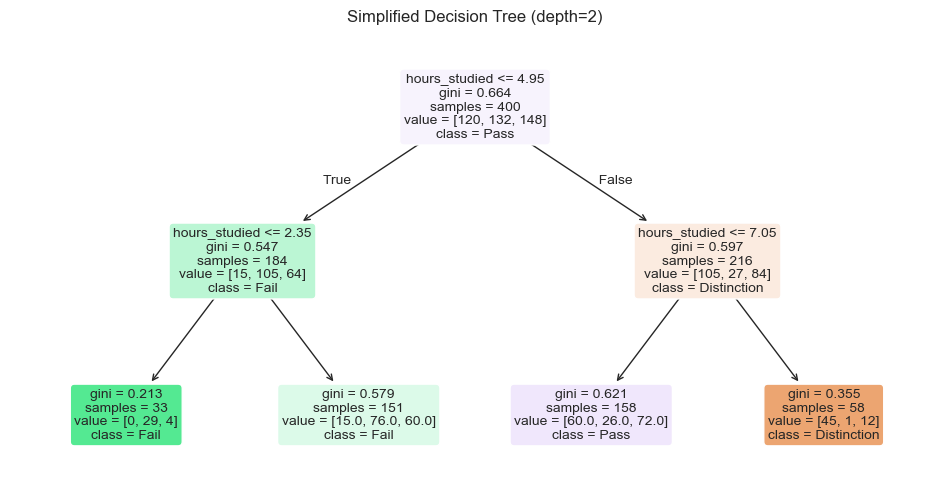

In [20]:
# Visualize the decision tree
tree_model_simple = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model_simple.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
plot_tree(
    tree_model_simple,
    feature_names=X_train.columns,
    class_names=tree_model_simple.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Simplified Decision Tree (depth=2)")
plt.show()

# Section 6: K-Means Clustering 

In [ ]:
# Select features for clustering that are behavior-related
cluster_features = ["hours_studied", "attendance_percent", "sleep_hours", "assignment_score", "previous_scores"]
X_cluster = df[cluster_features]

# Scale the features - KMeans is distance-based, so features must be on the same scale
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [22]:
# Apply K-Means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

# See how many students fell into each cluster
df["Cluster"].value_counts()

c:\Users\princ\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Cluster
2    195
0    167
1    138
Name: count, dtype: int64

In [ ]:
# Look at the average feature values per cluster 
df.groupby("Cluster")[cluster_features].mean()


,hours_studied,attendance_percent,sleep_hours,assignment_score,previous_scores
Cluster,,,,,
0,5.440120,85.286228,6.174850,66.120958,76.337126
1,6.034783,70.436232,5.989855,77.044203,58.631884
2,3.912821,82.602564,7.467179,69.299487,59.356923


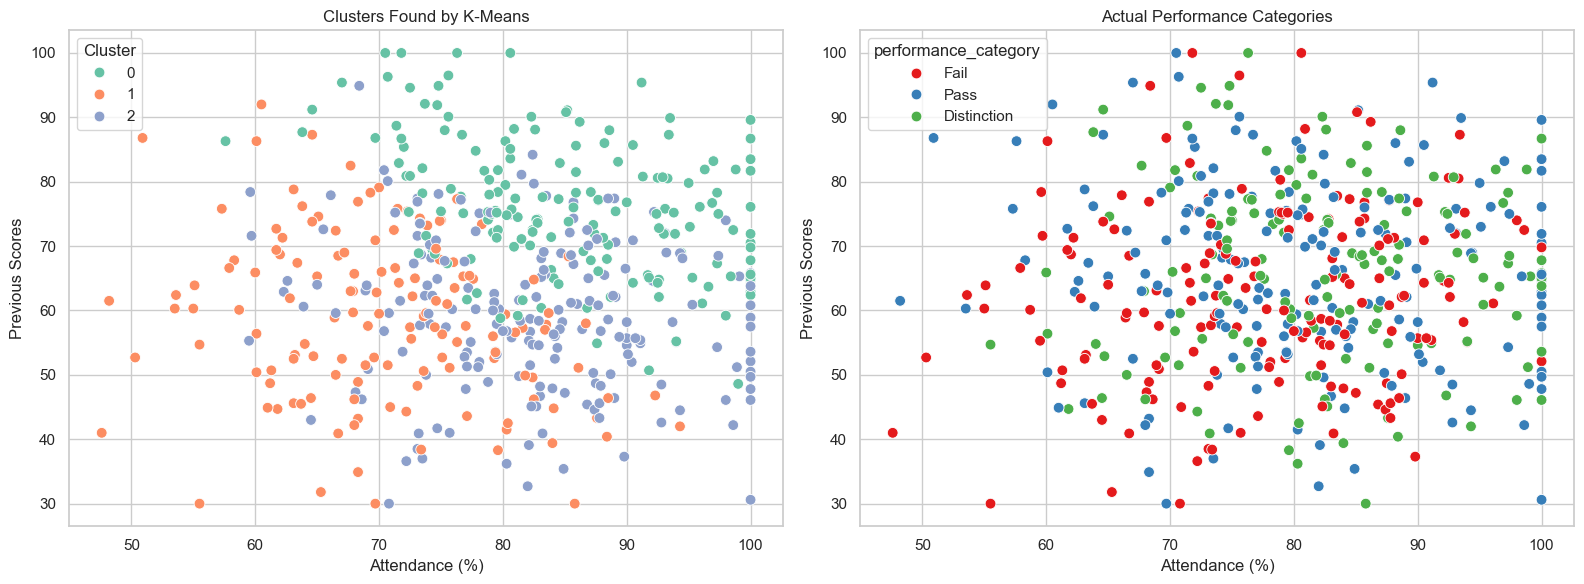

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: colored by K-Means cluster (what the model found on its own)
sns.scatterplot(
    data=df, x="attendance_percent", y="previous_scores",
    hue="Cluster", palette="Set2", s=60, ax=axes[0]
)
axes[0].set_title("Clusters Found by K-Means")
axes[0].set_xlabel("Attendance (%)")
axes[0].set_ylabel("Previous Scores")

# Right plot: colored by actual performance category (the real answer)
sns.scatterplot(
    data=df, x="attendance_percent", y="previous_scores",
    hue="performance_category", palette="Set1", s=60, ax=axes[1],
    hue_order=["Fail", "Pass", "Distinction"]
)
axes[1].set_title("Actual Performance Categories")
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("Previous Scores")

plt.tight_layout()
plt.show()

# Section 7: Neural Network 

In [26]:
# Create and train a neural network
nn_model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
nn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_nn = nn_model.predict(X_test_scaled)

# Section 8: Evaluation and Comparison

In [40]:
# Function to calculate and print metrics for a model's predictions
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}\n")
    return acc, prec, rec, f1
log_metrics = evaluate_model("Logistic Regression", y_test, y_pred_log)
tree_metrics = evaluate_model("Decision Tree", y_test, y_pred_tree)
nn_metrics = evaluate_model("Neural Network", y_test, y_pred_nn)

--- Logistic Regression ---
Accuracy:  0.660
Precision: 0.654
Recall:    0.660
F1-score:  0.655

--- Decision Tree ---
Accuracy:  0.480
Precision: 0.505
Recall:    0.480
F1-score:  0.471

--- Neural Network ---
Accuracy:  0.610
Precision: 0.600
Recall:    0.610
F1-score:  0.602



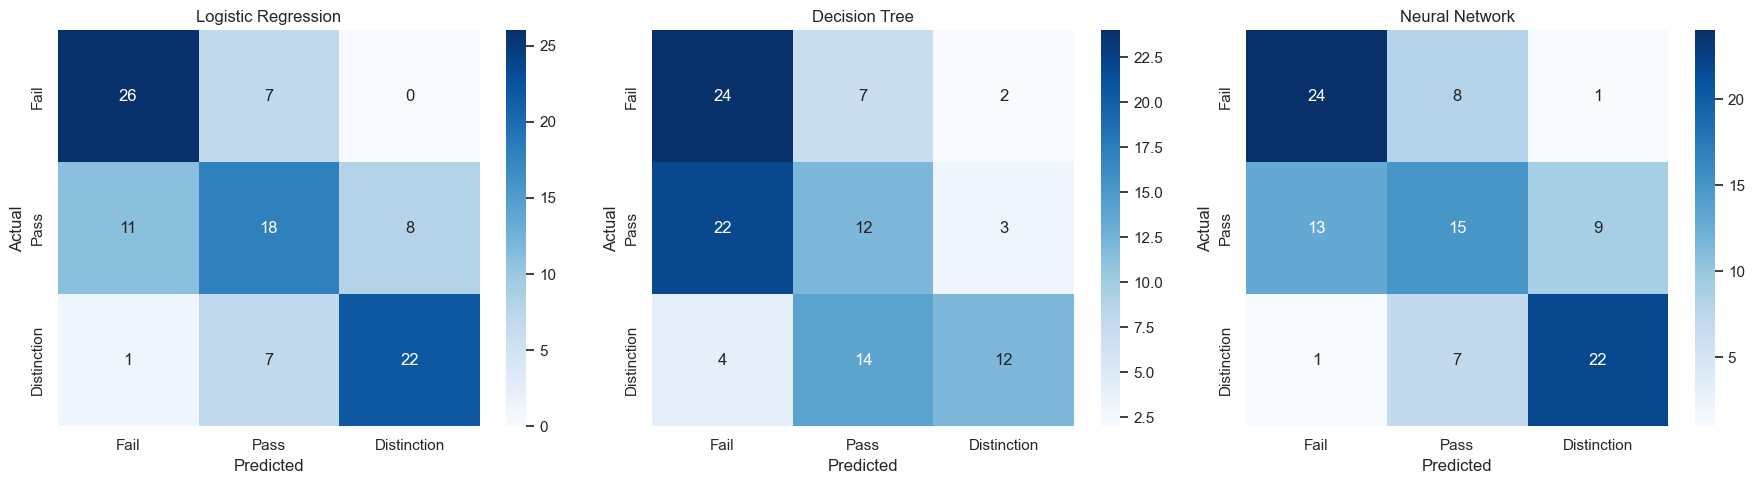

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree),
    ("Neural Network", y_pred_nn),
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds, labels=["Fail", "Pass", "Distinction"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fail", "Pass", "Distinction"],
                yticklabels=["Fail", "Pass", "Distinction"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [29]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Neural Network"],
    "Accuracy": [log_metrics[0], tree_metrics[0], nn_metrics[0]],
    "Precision": [log_metrics[1], tree_metrics[1], nn_metrics[1]],
    "Recall": [log_metrics[2], tree_metrics[2], nn_metrics[2]],
    "F1-score": [log_metrics[3], tree_metrics[3], nn_metrics[3]],
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.66,0.653914,0.66,0.654734
1,Decision Tree,0.48,0.504710,0.48,0.470892
2,Neural Network,0.61,0.599671,0.61,0.601673


In [30]:
# Cross-tabulate clusters against actual performance categories
pd.crosstab(df["Cluster"], df["performance_category"])

performance_category,Distinction,Fail,Pass
Cluster,,,
0,63,39,65
1,49,45,44
2,38,81,76


## Ethical Discussion

While this project demonstrates the potential of machine learning to predict student 
performance, its real-world deployment raises several ethical concerns that must be 
considered.

**Risk of Labeling and Self-Fulfilling Prophecies**
Predicting that a student is likely to "Fail" could unintentionally influence how 
teachers, parents, or the students themselves perceive their ability. If a student is 
labeled at-risk early on, this label could lower expectations and become a 
self-fulfilling prophecy rather than a helpful early warning.

**Data Privacy**
Student data such as attendance, sleep patterns, and academic history is sensitive. 
Any real deployment of this system would need to ensure data is collected with consent, 
stored securely, and used only for its intended purpose of supporting students, not 
for punitive measures.

**Bias and Fairness**
This project used a synthetic dataset built with straightforward, controlled 
relationships between features. A real-world dataset could reflect existing 
inequalities, for example, students from under-resourced backgrounds might show 
lower attendance due to circumstances outside their control (transport, home 
responsibilities, health), not lack of effort. A model trained on such data could 
unfairly penalize students for systemic issues rather than individual choices.

**Over-Reliance on Automated Predictions**
Machine learning predictions should support human judgment, not replace it. A teacher 
who knows a student's personal circumstances may recognize context a model cannot see. 
This system should be used as a decision-support tool alongside teacher input, not as 
a sole determinant of a student's academic path.

**Transparency**
Students and parents affected by such predictions should be informed about how the 
system works and have the ability to question or appeal predictions that don't reflect 
their real circumstances.

## Challenges Encountered

**Missing Values**
The dataset contained missing values in `sleep_hours` and `assignment_score`. This 
was resolved by imputing the median of each column, which preserves the affected 
rows while minimizing the influence of outliers on the replacement value.

**Class Imbalance in Category Design**
An early version of the performance category used fixed score thresholds (e.g. below 
50 = Fail), which resulted in a heavily imbalanced dataset (401 Pass, 32 Fail). This 
was resolved by switching to percentile-based thresholds, producing a more balanced 
and evaluable set of categories.

**Data Leakage Risk**
Since `performance_category` was directly derived from `exam_score`, an early design 
risk was accidentally including `exam_score` as an input feature, which would have 
allowed the model to "cheat" rather than learn genuine patterns. This was addressed 
by explicitly excluding `exam_score` from the feature set used for training.

**Lower Decision Tree Accuracy**
The Decision Tree model achieved noticeably lower accuracy (48%) compared to Logistic 
Regression and the Neural Network. This is a trade-off of limiting `max_depth` to 
avoid overfitting; a deeper tree may have performed better on this specific test set 
but would generalize worse to new data and be harder to interpret.

**Visualizing Multi-Dimensional Clusters**
Since K-Means clustering used five features simultaneously, the clusters could not be 
directly visualized in a single 2D plot. This was addressed by selecting the two 
features with the clearest separation between cluster averages for visualization, 
while acknowledging the clustering itself considered all five features.

## Conclusion and Recommendations

### Conclusion

This project applied machine learning techniques to predict student academic 
performance based on study habits, attendance, sleep, assignment scores, and past 
academic history. A dataset of 500 students was cleaned, explored, and used to train 
three classification models (Logistic Regression, Decision Tree, and a Neural Network), 
alongside K-Means clustering to uncover natural behavioral groupings among students.

Logistic Regression achieved the best performance among the classification models, 
with 66% accuracy, followed by the Neural Network (61%) and Decision Tree (48%). This 
suggests that the relationship between student behavior and academic outcomes in this 
dataset is largely linear and additive, favoring simpler models over more complex ones. 
The Decision Tree, while less accurate, offered the clearest interpretability, directly 
showing which features (attendance and study hours) most influenced predictions.

K-Means clustering, despite having no access to actual performance labels, uncovered 
three behavioral groups that showed a meaningful relationship with real outcomes: 
consistent attendees leaned toward better results, low-effort students leaned toward 
Fail, and "hard workers with attendance gaps" showed the most mixed outcomes. This 
confirms that behavioral patterns alone carry real predictive signal, even without 
labeled data.

In practice, this system could be integrated into a school's existing student 
information system to flag at-risk students each term, allowing academic advisors 
to prioritize outreach and support before final exams rather than after grades are 
released. It could also help students track how their own habits, such as attendance 
and study time, relate to their likely outcomes, encouraging proactive changes.

Overall, the project demonstrates that machine learning can meaningfully support early 
identification of at-risk students, though no model achieved particularly high accuracy, 
reflecting the genuine complexity and unpredictability of human academic performance.

### Recommendations

1. **Use predictions as a support tool, not a final verdict.** Teachers and academic 
advisors should treat model outputs as an early-warning signal to prompt further 
conversation with a student, not as an automatic determination of their ability.

2. **Collect richer, real-world data for future work.** This project relied on a 
synthetic dataset with five behavioral features. A production system would benefit 
from richer, real data, such as subject-specific performance, socioeconomic context, 
or engagement with learning resources, to improve accuracy and fairness.

3. **Regularly re-evaluate the model for bias.** If deployed with real student data, 
the model should be periodically audited to check whether it disproportionately flags 
students from particular backgrounds, to avoid reinforcing existing inequalities.

4. **Combine multiple models rather than relying on one.** Since Logistic Regression, 
the Decision Tree, and the Neural Network each captured slightly different patterns, 
an ensemble approach or a simple majority vote across models could improve robustness 
in a real deployment.